# OPTIONAL Workbook for Final Project, Part 3

Your group is welcome to work on a local version of a notebook for this assignment.

This workspace is here if you'd rather not have to install all necessary packages locally.

You can download any json files to your local computer to add them to your local jekyll page.

To download, you can right-click on the file and hit download.  For example, with the following code:

```python
from vega_datasets import data
import altair as alt

source = data.cars()
source.rename(columns={"Miles_per_Gallon":"Miles per Gallon"}, 
              inplace=True)


chart = alt.Chart(source).mark_circle(size=60).encode(
    x='Horsepower',
    y='Miles per Gallon',
    color='Origin',
    tooltip=['Name', 'Origin', 'Horsepower', 'Miles per Gallon']
).interactive()

chart.properties(width='container').save("cars.json")
```

You can download from the side bar like this:

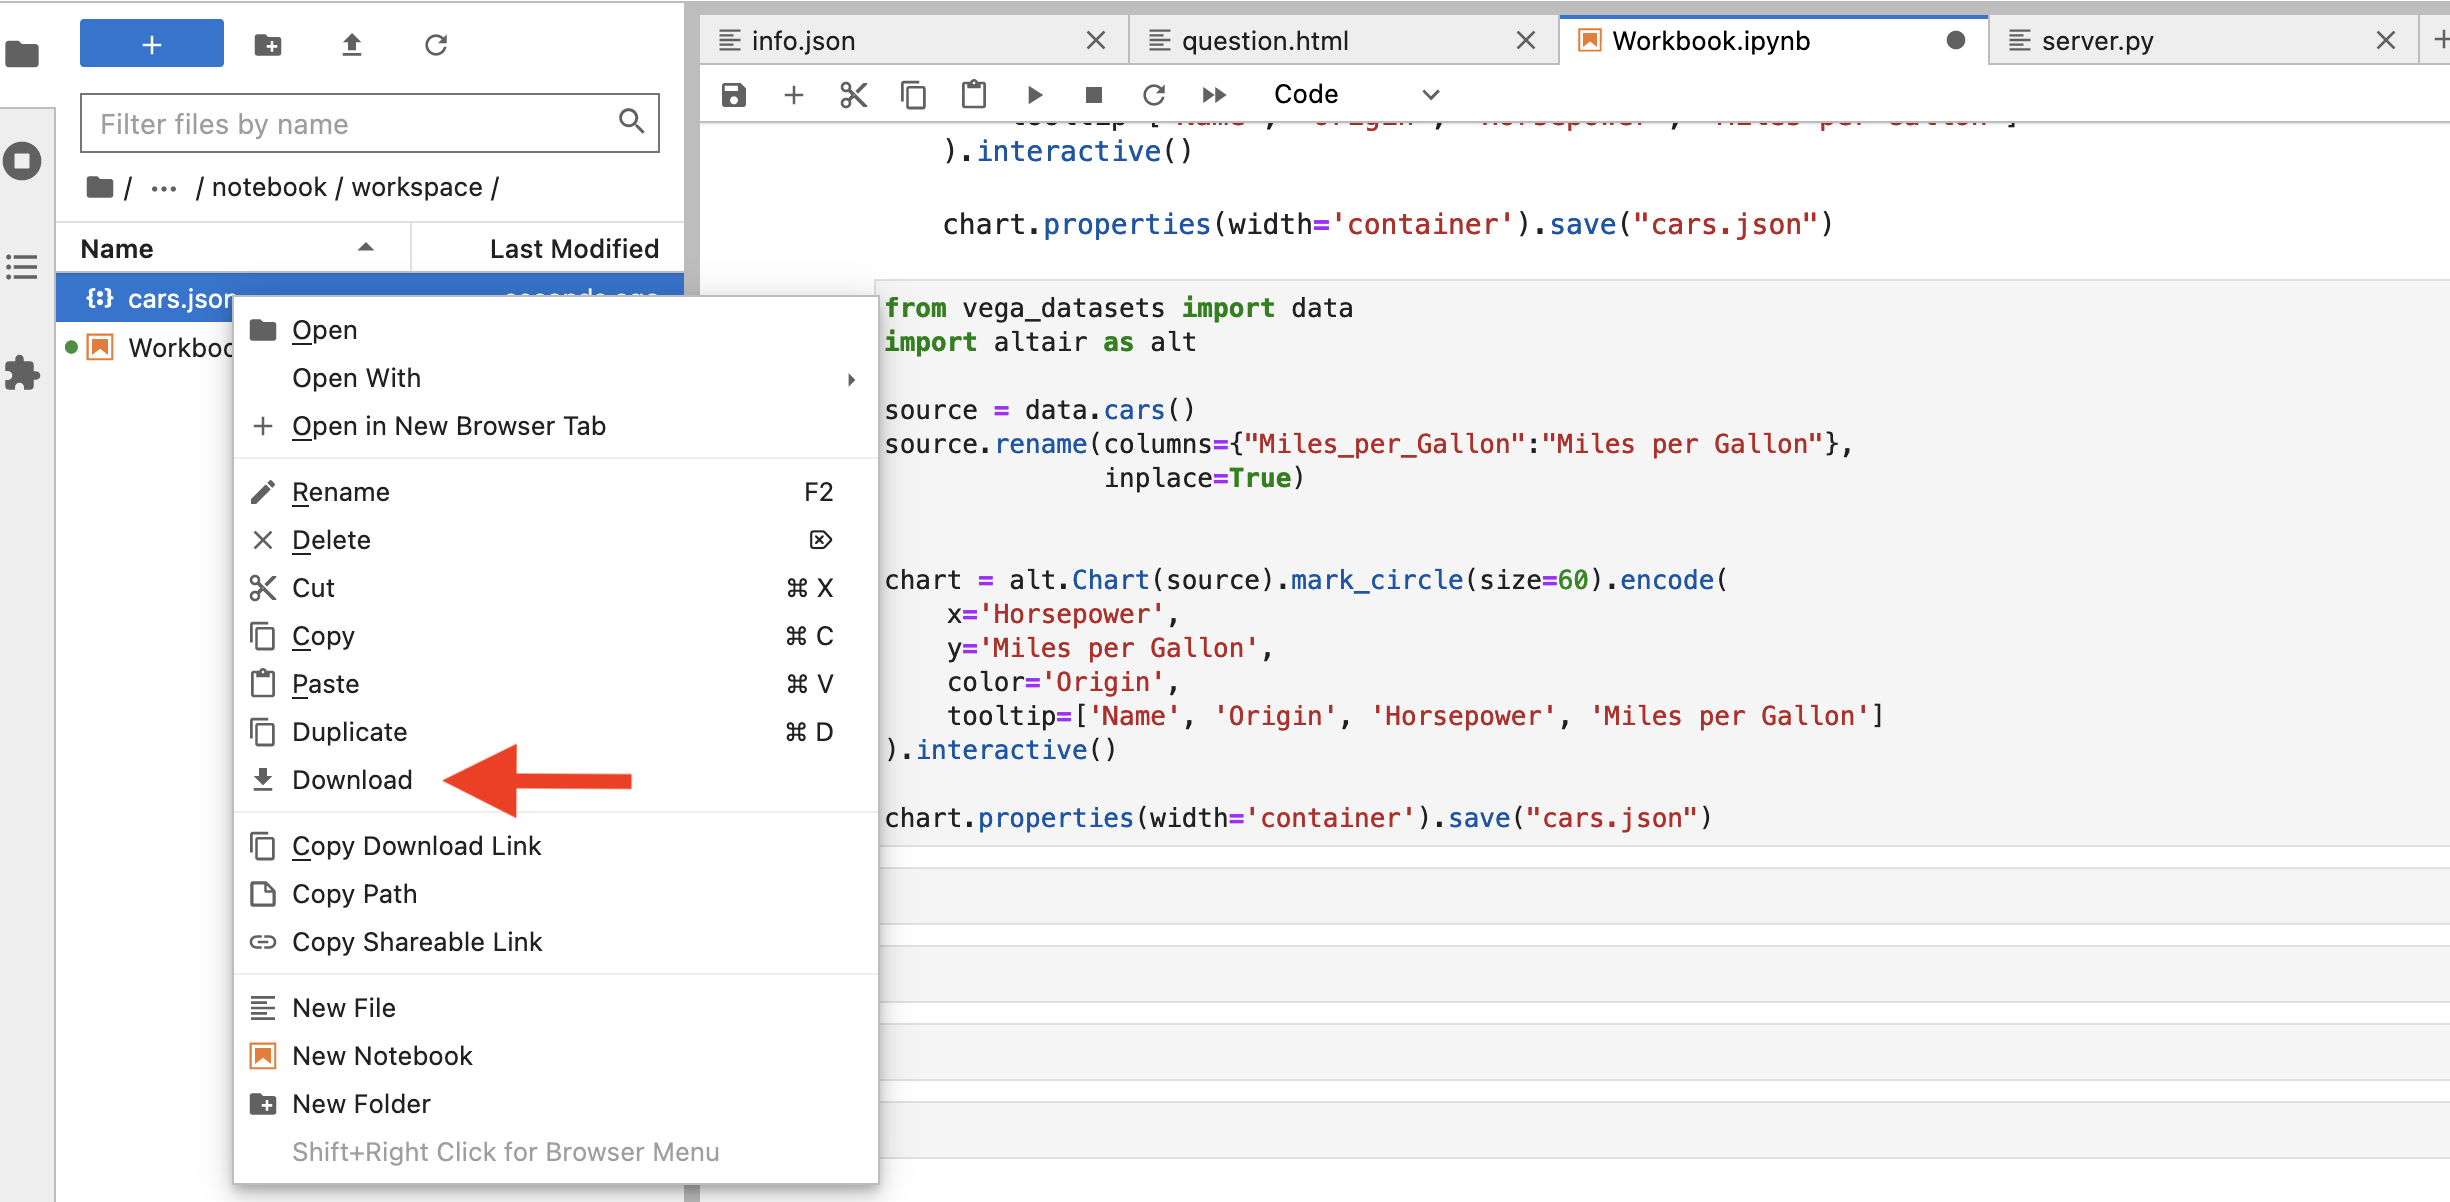

Contextual Visualization 1 - Land & Ocean Temperature Percentiles (2025

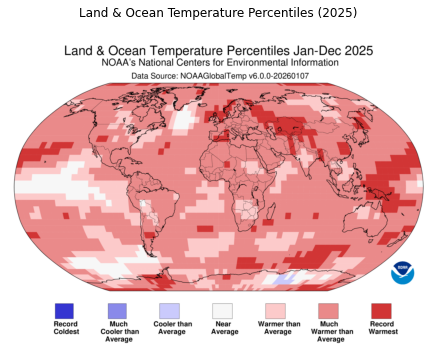

In [50]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open('map-percentile-mntp-202501-202512.png')

plt.figure(figsize=(10,6))
plt.imshow(img)
plt.axis('off') 
plt.title("Land & Ocean Temperature Percentiles (2025)")

plt.show()

Context about global warming and how rising temperatures impact storm activity.

Global warming is the leading cause to recording changes in temperature across the globe. Tempartures continue to rise each year. This is impacting the storm activity signicantly. It is causing more storms to happen more rapidly and have more storms predicted per year than expected. It effects all storm types no matter the geographic location. Global warming can increase rainfall, sea level rising and hotter temparatures. In the image above, majority of the globe is warmer than average, this is not normal. The near average temperatures are mainly in the ocean. 

Source: NOAA National Centers for Environmental Information (NCEI). 
Land & Ocean Temperature Percentiles, 2025. 
Dataset: NOAAGlobalTemp v6.0.0. https://www.ncei.noaa.gov/sites/default/files/inline-images/map-percentile-mntp-202501-202512.png

In [42]:
disasters_df = pd.read_csv("DisasterDeclarationsSummaries.csv")
disasters_df = fema_df.dropna(subset=["incidentType"]).copy()

incident_counts = (fema_df["incidentType"].value_counts().head(10).reset_index())

incident_counts.columns = ["incidentType", "count"]

disasters_chart = (alt.Chart(incident_counts).mark_bar().encode(
            x=alt.X(
            "incidentType:N",
            sort="-y",
            title="Incident Type",
            axis=alt.Axis(labelAngle=45)
        ),
        y=alt.Y(
            "count:Q",
            title="Number of FEMA Disaster Declarations"
        ),tooltip=[
            alt.Tooltip("incidentType:N", title="Incident Type"),
            alt.Tooltip("count:Q", title="Declarations")])
    .properties(
        width=500,
        height=400,
        title="Top FEMA Disaster Declaration Incident Types"
    )
)

disasters_chart

alt.Chart(...)

Why do we need to "double-check" with FEMA data?

While meteorological data tells us how often a storm occurred, this FEMA chart demonstrates how much those storms actually impacted our communities. There is a critical gap between observing a weather event and officially declaring a national disaster. This FEMA disaster declaration chart represents a threshold of severity that demands federal intervention. By "double-checking" the weather frequency against this dataset, we can identify which events are truly the most dangerous to our infrastructure and safety.
The dominance of categories like "Severe Storm" and "Hurricane" in these declarations shows that these are not just frequent weather patterns, but our primary national threats. It reminds us that these are the specific disasters we must prioritize in mitigation. Ultimately, this visualization moves us beyond simple weather tracking and provides a clear roadmap for where our attention and resources will save the most lives.

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import altair as alt 
from vega_datasets import data

df = pd.read_csv("StormEvents_details-ftp_v1.0_d2025_c20260323.csv")
marine_events =  df["EVENT_TYPE"].str.contains("Marine|Waterspout", case=False, na=False)
      
state_df = df[~marine_events].copy()

In [44]:
viz1_df = state_df.dropna(subset = ['STATE','EVENT_TYPE']).copy()

counts = (viz1_df.groupby(["STATE", "EVENT_TYPE"]).size().reset_index(name='count'))
counts = counts.sort_values(["STATE", "count"], ascending=[True, False])
counts = counts.groupby("STATE").head(10)

dropdown = alt.binding_select(options = sorted(viz1_df["STATE"].unique()),
                             name = "Select State: ")

state_select = alt.selection_point(fields = ["STATE"],
                                  bind = dropdown,
                               value = [{"STATE": sorted(viz1_df["STATE"].unique())[0]}])

bar_chart= (alt.Chart(counts).mark_bar().encode(
                               x = alt.X("EVENT_TYPE:N",
                                        sort = '-y',
                                        title = "Storm Type",
                                        axis = alt.Axis(labelAngle = 45,labelFontSize = 12)
                                        ),
                                y = alt.Y("count:Q", title = "Number of Events"),
                                tooltip = ["EVENT_TYPE", "count"]
                                ).add_params(state_select)
                                .transform_filter(state_select)
                                .properties(width = 500,
                                           height = 500,
                                           title = "Most Common Storm Types by State"
                                )
           )

bar_chart

alt.Chart(...)

Which Storms are Most Common in Our State?

This interactive chart answers a critical question for every community that "Which weather hazards should we prioritize our resources for?" By clicking the 'Select State' dropdown, you can explore the top 10 storm types for any state impacted in 2025. This provides essential data for both local governments and residents to determine where mitigation of the disaster budgets and emergency preparations can be utilized most efficiently.
For instance, if we look at Illinois, "Thunderstorm Wind" stands out as the overwhelmingly dominant threat with nearly 1,000 recorded events. While "Hail" is the second most frequent hazard with approximately 300 cases, it is relatively minor compared to the volume of thunderstorm wind. Most other storm types in the state maintain a much lower, steady frequency. This specific data highlights that for Illinois, focusing on infrastructure resilience against wind damage is a much more effective strategy than preparing for all storm types equally.

In [45]:
bar_chart.save("bar_chart.html")
disasters_chart.save("disasters_chart.html")
plt.savefig("map-percentile-mntp-202501-202512.png", bbox_inches="tight", dpi=300)

<Figure size 432x288 with 0 Axes>

In [53]:
import altair as alt
alt.data_transformers.disable_max_rows()

disasters_chart.save('fema_disasters.json')

bar_chart.save('state_storms.json')